# Анализ маркетплейса Olist

Python + Pandas визуализация для проекта по анализу маркетплейса Olist.

Цель ноутбука — загрузить CSV-данные, повторить ключевые метрики, построить графики и сохранить изображения для README.

## 0. Импорт библиотек

In [118]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Загрузка данных

In [119]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
translation = pd.read_csv("../data/product_category_name_translation.csv")

## 2. Проверка данных

In [120]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order items:", order_items.shape)
print("Payments:", payments.shape)
print("Products:", products.shape)

Orders: (99441, 8)
Customers: (99441, 5)
Order items: (112650, 7)
Payments: (103886, 5)
Products: (32951, 9)


## 3. Анализ статусов заказов

In [121]:
status_counts = (
    orders.groupby("order_status")
          .size()
          .sort_values(ascending=False)
)

status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
dtype: int64

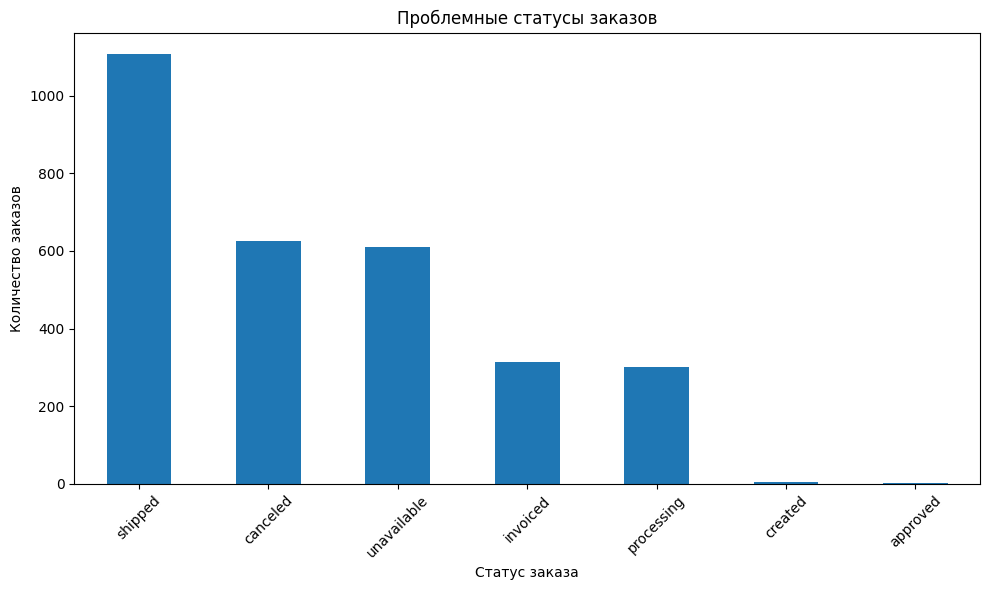

In [122]:
problem_orders = status_counts.drop("delivered")

plt.figure(figsize=(10, 6))
problem_orders.plot(kind="bar")

plt.title("Проблемные статусы заказов")
plt.xlabel("Статус заказа")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/problem_order_statuses.png", dpi=200)
plt.show()

## 4. Самые продаваемые категории товаров

In [123]:
sales = (
    order_items
    .merge(products, on="product_id")
    .merge(translation, on="product_category_name")
)

top_categories = (
    sales.groupby("product_category_name_english")
         .size()
         .sort_values(ascending=False)
         .head(10)
)

top_categories

product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
dtype: int64

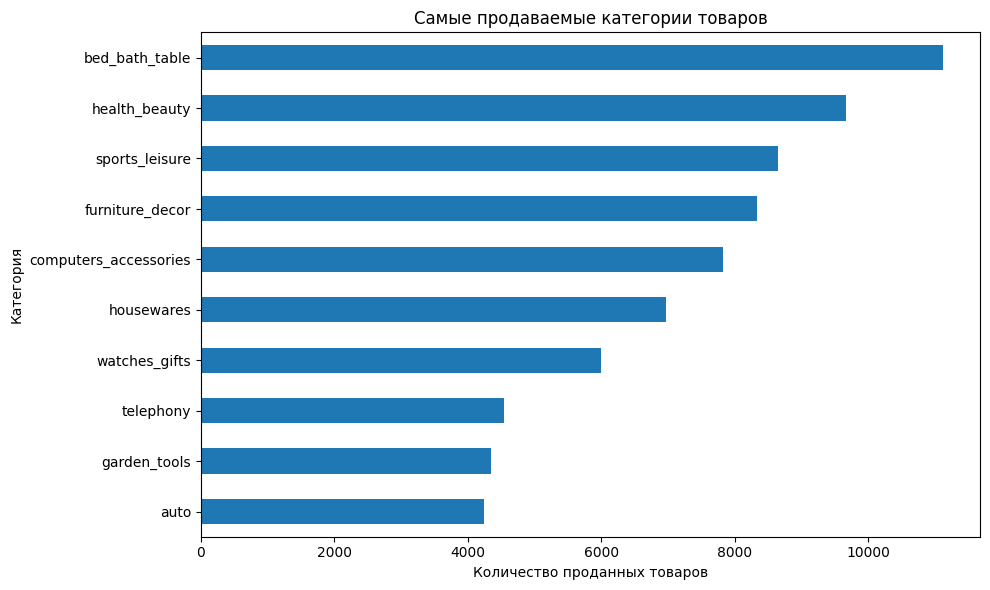

In [124]:
plt.figure(figsize=(10, 6))

top_categories.sort_values().plot(kind="barh")

plt.title("Самые продаваемые категории товаров")
plt.xlabel("Количество проданных товаров")
plt.ylabel("Категория")

plt.tight_layout()
plt.savefig("../images/top_categories.png", dpi=200)
plt.show()

## 5. Категории с наибольшей выручкой

In [125]:
sales_with_payments = sales.merge(payments, on="order_id")

revenue_by_category = (
    sales_with_payments
    .groupby("product_category_name_english")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

revenue_by_category

product_category_name_english
bed_bath_table           1712553.67
health_beauty            1657373.12
computers_accessories    1585330.45
furniture_decor          1430176.39
watches_gifts            1429216.68
sports_leisure           1392127.56
housewares               1094758.13
auto                      852294.33
garden_tools              838280.75
cool_stuff                779698.00
Name: payment_value, dtype: float64

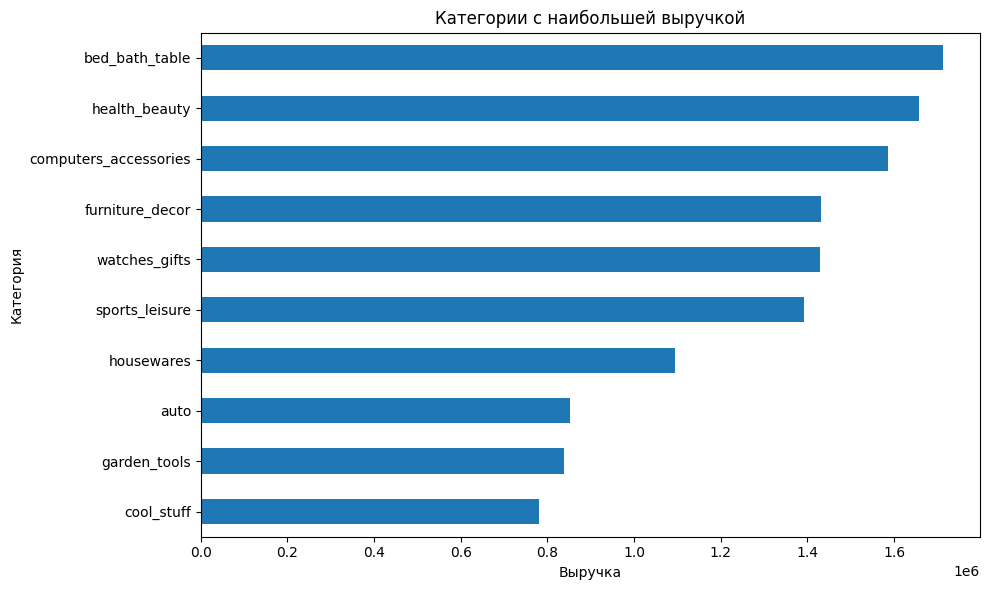

In [126]:
plt.figure(figsize=(10, 6))

revenue_by_category.sort_values().plot(kind="barh")

plt.title("Категории с наибольшей выручкой")
plt.xlabel("Выручка")
plt.ylabel("Категория")

plt.tight_layout()
plt.savefig("../images/revenue_categories.png", dpi=200)
plt.show()

## 6. Динамика заказов и выручки по месяцам

In [127]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M").astype(str)

monthly_orders = (
    orders.groupby("order_month")
          .size()
          .reset_index(name="orders_count")
)

monthly_revenue = (
    orders[["order_id", "order_month"]]
    .merge(payments, on="order_id")
    .groupby("order_month")["payment_value"]
    .sum()
    .reset_index(name="revenue")
)

monthly = monthly_orders.merge(monthly_revenue, on="order_month")

monthly.head()

,order_month,orders_count,revenue
0,2016-09,4,252.24
1,2016-10,324,59090.48
2,2016-12,1,19.62
3,2017-01,800,138488.04
4,2017-02,1780,291908.01


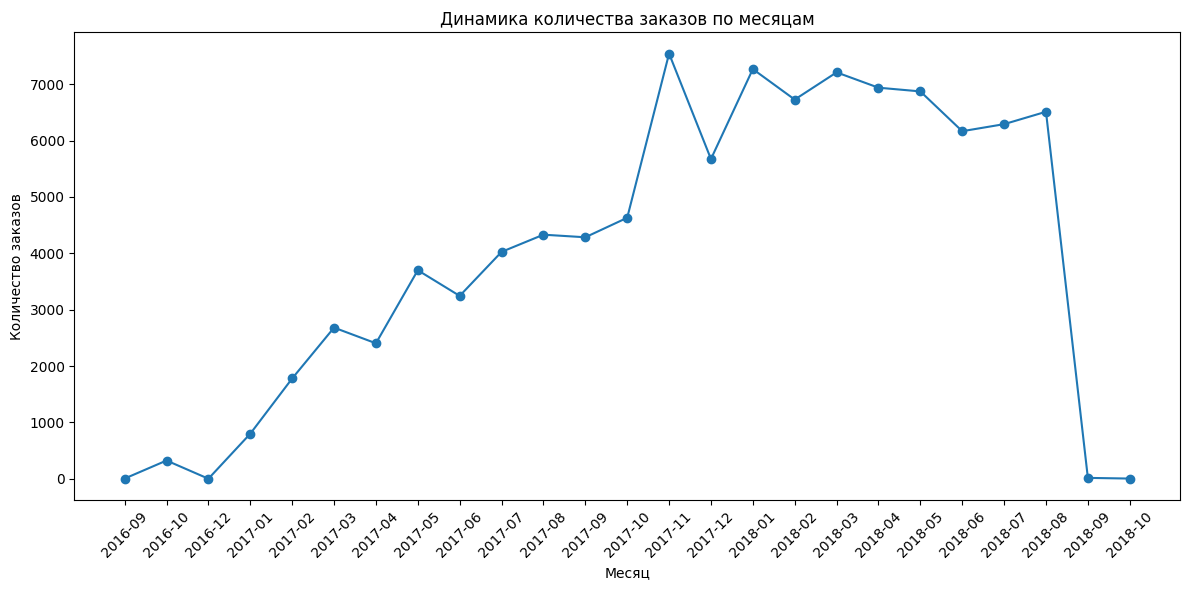

In [128]:
plt.figure(figsize=(12, 6))

plt.plot(monthly["order_month"], monthly["orders_count"], marker="o")

plt.title("Динамика количества заказов по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Количество заказов")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/monthly_orders.png", dpi=200)
plt.show()

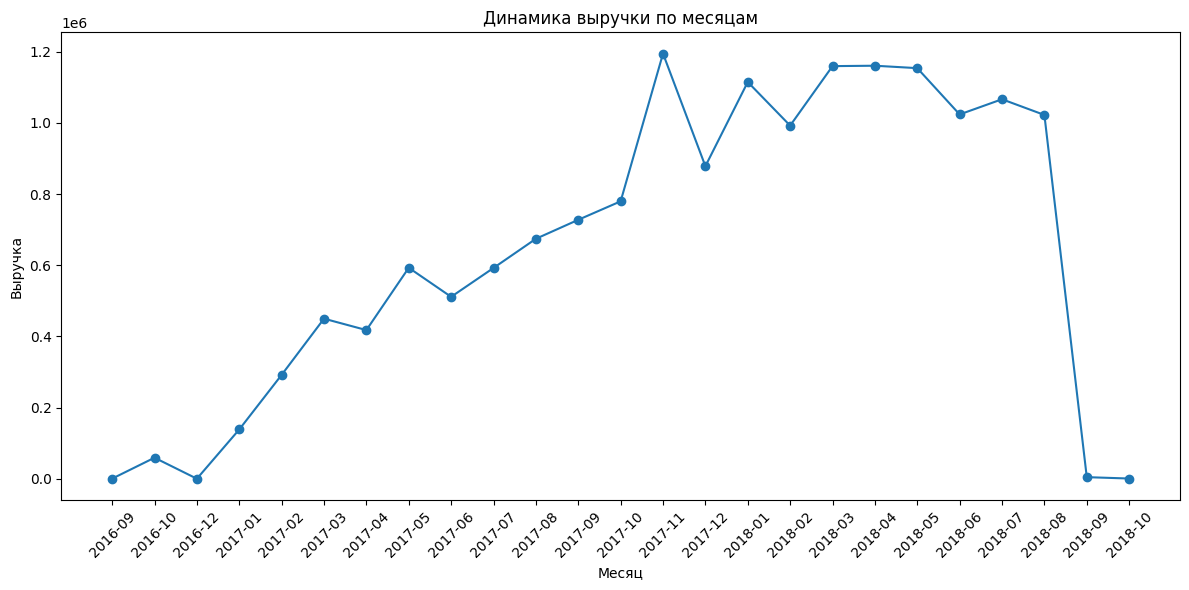

In [129]:
plt.figure(figsize=(12, 6))

plt.plot(monthly["order_month"], monthly["revenue"], marker="o")

plt.title("Динамика выручки по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Выручка")
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("../images/monthly_revenue.png", dpi=200)
plt.show()

## 7. Ключевые выводы

- Маркетплейс обработал 99 441 заказ при 96 096 уникальных клиентах.
- Общая выручка составила 16 008 872.12.
- Средний чек составил 154.10.
- 97.02% заказов были успешно доставлены клиентам.
- Только 3.12% клиентов совершили повторную покупку, что говорит о низком уровне удержания.
- Категории `bed_bath_table`, `health_beauty` и `sports_leisure` лидируют по количеству проданных товаров.
- Категории `bed_bath_table`, `health_beauty` и `computers_accessories` принесли наибольшую выручку.
- Среди проблемных статусов чаще всего встречаются `shipped`, `canceled` и `unavailable`.

## 8. Бизнес-интерпретация результатов

- Основная точка роста маркетплейса — удержание клиентов и увеличение доли повторных покупок.
- Логистические процессы работают стабильно: более 97% заказов были успешно доставлены.
- Особого внимания требуют заказы со статусами `canceled` и `unavailable`, так как они напрямую влияют на клиентский опыт и выручку.
- Категории товаров для дома и красоты формируют основной объём продаж.
- Электроника и компьютерные аксессуары важны для выручки из-за более высокой стоимости заказа.